# 03-Rolling Deployments & Scaling Strategies (Kubernetes Deployments)

Lesson 02 gave the cluster a reflex: HPA and VPA continuously resize *how much* capacity exists in response to load. But neither controller ever asked *what code* is running inside those Pods. Sooner or later, someone ships `api-backend:1.5.0` to replace `1.4.0`, and now we face a different problem entirely — how do you replace every running instance of a service with a new version, at scale, without a single dropped request?

A naive approach — delete every old Pod, then create every new Pod — guarantees an outage window exactly as long as the new image takes to pull and become ready. Kubernetes' **Deployment** controller solves this with a **RollingUpdate** strategy: it advances the new ReplicaSet and retires the old one incrementally, governed by two small integers that encode a precise availability/velocity tradeoff. This lesson formalizes that arithmetic and the readiness-gating logic that makes it safe, using **Kubernetes Deployments** as the mechanism.

## 1. The Combinatorics of Zero-Downtime Rollout

### ReplicaSet Succession

A Deployment never directly owns Pods — it owns a chain of **ReplicaSets**, one per revision. Rolling from revision $v_{old}$ (with $R$ desired replicas) to $v_{new}$ is a controller loop that adjusts two live counters, $\text{Ready}(RS_{old})$ and $\text{Ready}(RS_{new})$, on every tick until:

$$\text{Ready}(RS_{old}) = 0 \quad \land \quad \text{Ready}(RS_{new}) = R$$

### The maxSurge / maxUnavailable Bound

Two fields on the `RollingUpdate` strategy bound how aggressively the controller may move at each tick, both expressible as an absolute count or a percentage of $R$:

$$\text{maxUnavailable} = \lfloor R \times p_u \rfloor, \qquad \text{maxSurge} = \lceil R \times p_s \rceil$$

At every instant during the rollout, the controller enforces two simultaneous inequalities across *both* ReplicaSets combined:

$$\text{TotalPods} \le R + \text{maxSurge} \qquad \text{and} \qquad \text{AvailablePods} \ge R - \text{maxUnavailable}$$

The default Kubernetes values are $p_u = p_s = 25\%$: a Deployment may briefly run up to $1.25R$ total Pods (surge above target) while never dropping below $0.75R$ available Pods (tolerated unavailability). Setting $\text{maxUnavailable}=0$ guarantees the union is never below $R$ available Pods at the cost of always surging; setting $\text{maxSurge}=0$ guarantees the cluster never exceeds $R$ total Pods at the cost of tolerating dips in availability — a direct speed-vs-safety dial.

### Readiness Gating and the Probability of a Bad Rollout

A new Pod only counts toward $\text{Ready}(RS_{new})$ after passing its `readinessProbe` for `minReadySeconds` continuously. If each probe attempt independently succeeds with probability $q$ (a genuinely healthy new image has $q \to 1$; a broken image has $q \to 0$), the probability that a single new Pod is marked ready within $k$ probe attempts (each with independent failure) is:

$$P(\text{ready within } k) = 1 - (1-q)^k$$

This is precisely why a broken new image *never* achieves the required ready count and the rollout **stalls** rather than completing — the controller has no notion of "rollout failure," only "rollout not yet converged," which is what makes an automated `kubectl rollout undo` (reverting the Deployment's desired revision) the correct recovery primitive rather than any explicit failure branch.

### Rollout Progression as a Markov-like Step Sequence

For $R = 4$, $\text{maxSurge}=1$, $\text{maxUnavailable}=1$, one valid controller trajectory (old, new) pairs is: $(4,0) \to (3,1) \to (3,2)\ [\text{surge}] \to (2,2) \to (1,3) \to (0,4)$ — old count monotonically decreases, new count monotonically increases, and the surge/unavailable bounds hold at every intermediate step. We simulate exactly this stepping logic below.

## 2. Imperative Execution: Simulating the RollingUpdate State Machine

We author a real `Deployment` manifest with an explicit `RollingUpdate` strategy, then drive the exact surge/unavailable-bounded stepping algorithm the Deployment controller runs internally, since no live cluster exists in this sandbox.

In [1]:
# Required installations: pip install kubernetes pyyaml

import yaml
import math

print("--- 🚀 Initializing Rolling Deployment State-Machine Sandbox ---")

# 1. Author a real Deployment manifest with an explicit RollingUpdate strategy
deployment_manifest = {
    "apiVersion": "apps/v1",
    "kind": "Deployment",
    "metadata": {"name": "api-backend", "namespace": "ml-workloads"},
    "spec": {
        "replicas": 8,
        "strategy": {
            "type": "RollingUpdate",
            "rollingUpdate": {"maxSurge": "25%", "maxUnavailable": "25%"},
        },
        "minReadySeconds": 10,
        "template": {"spec": {"containers": [{"name": "api-backend", "image": "registry.local/api-backend:1.5.0"}]}},
    },
}
with open("deployment_rolling.yaml", "w") as f:
    yaml.dump(deployment_manifest, f, sort_keys=False)
print("   ✅ Deployment manifest (replicas=8, maxSurge=25%, maxUnavailable=25%) compiled to disk")

# 2. Derive the integer bounds from the percentage strategy
R = deployment_manifest["spec"]["replicas"]
p_surge = 0.25
p_unavail = 0.25
max_surge = math.ceil(R * p_surge)
max_unavailable = math.floor(R * p_unavail)
print(f"   Derived bounds: maxSurge={max_surge} pods, maxUnavailable={max_unavailable} pods (R={R})")

print("\n--- 🧮 Executing RollingUpdate Controller Loop (v1.4.0 -> v1.5.0) ---")

try:
    from kubernetes import client, config
    config.load_kube_config()
    apps_v1 = client.AppsV1Api()
    dep = apps_v1.read_namespaced_deployment_status("api-backend", "ml-workloads")
    print(f"   Connected to live cluster. Current rollout status: {dep.status}")
except Exception as e:
    print("   [SYSTEM NOTE]: No live Deployment controller reachable in this sandbox -- replaying the")
    print("   surge/unavailable-bounded ReplicaSet succession algorithm in pure Python.")

    old_ready, new_ready = R, 0
    trajectory = [(old_ready, new_ready, "initial state (v1.4.0 fully ready)")]

    while old_ready > 0 or new_ready < R:
        total = old_ready + new_ready
        available = old_ready + new_ready  # both counted while ready; simplification: readiness == available here
        # Surge up: bring a new pod if under the surge ceiling and old still needs replacing
        if total < R + max_surge and new_ready < R:
            new_ready += 1
            action = "surge new v1.5.0 pod"
        # Retire old: safe to remove an old pod if availability would remain within tolerance
        elif (old_ready - 1) + new_ready >= R - max_unavailable and old_ready > 0:
            old_ready -= 1
            action = "retire old v1.4.0 pod"
        else:
            break
        trajectory.append((old_ready, new_ready, action))

    print(f"   ✅ Rollout converged in {len(trajectory) - 1} controller ticks: (old=0, new={R}) reached.")


--- 🚀 Initializing Rolling Deployment State-Machine Sandbox ---
   ✅ Deployment manifest (replicas=8, maxSurge=25%, maxUnavailable=25%) compiled to disk
   Derived bounds: maxSurge=2 pods, maxUnavailable=2 pods (R=8)

--- 🧮 Executing RollingUpdate Controller Loop (v1.4.0 -> v1.5.0) ---
   [SYSTEM NOTE]: No live Deployment controller reachable in this sandbox -- replaying the
   surge/unavailable-bounded ReplicaSet succession algorithm in pure Python.
   ✅ Rollout converged in 16 controller ticks: (old=0, new=8) reached.


## 3. Declarative Telemetry: The Rollout Trajectory Audit

We audit each controller tick exactly as `kubectl rollout status deployment/api-backend --watch` would stream it, verifying the surge and unavailability bounds hold at every single step -- never just at the start and end.

In [2]:
print("\n--- 🔍 Auditing the RollingUpdate Trajectory ---")
print(f"{'Tick':<5} | {'Old (v1.4.0)':<13} | {'New (v1.5.0)':<13} | {'Total':<7} | {'Available':<10} | {'Action'}")
print("-" * 90)
for t, (o, n, action) in enumerate(trajectory):
    total = o + n
    available = o + n
    print(f"{t:<5} | {o:<13} | {n:<13} | {total:<7} | {available:<10} | {action}")

bound_violations = sum(1 for o, n, _ in trajectory if (o + n) > R + max_surge or (o + n) < R - max_unavailable)

print("\n[OPERATIONAL INSIGHT]")
print(f"-> Every tick satisfies TotalPods <= R + maxSurge ({R + max_surge}) and AvailablePods >= R - maxUnavailable ({R - max_unavailable});")
print(f"   bound violations detected across the full trajectory: {bound_violations}.")
print("-> The controller never deletes an old pod until a replacement new pod is already counted ready --")
print("   this is what guarantees the Service's endpoint list never drops below the availability floor.")
print("-> Total pod count briefly exceeds R (the 'surge' phase) precisely because maxSurge > 0 allows it --")
print("   this costs transient extra compute in exchange for zero availability dip.")
print("-> If v1.5.0's readiness probe never passed (q -> 0 from Section 1), 'new_ready' would freeze below R")
print("   forever -- the correct remediation is `kubectl rollout undo`, not waiting longer.")



--- 🔍 Auditing the RollingUpdate Trajectory ---
Tick  | Old (v1.4.0)  | New (v1.5.0)  | Total   | Available  | Action
------------------------------------------------------------------------------------------
0     | 8             | 0             | 8       | 8          | initial state (v1.4.0 fully ready)
1     | 8             | 1             | 9       | 9          | surge new v1.5.0 pod
2     | 8             | 2             | 10      | 10         | surge new v1.5.0 pod
3     | 7             | 2             | 9       | 9          | retire old v1.4.0 pod
4     | 7             | 3             | 10      | 10         | surge new v1.5.0 pod
5     | 6             | 3             | 9       | 9          | retire old v1.4.0 pod
6     | 6             | 4             | 10      | 10         | surge new v1.5.0 pod
7     | 5             | 4             | 9       | 9          | retire old v1.4.0 pod
8     | 5             | 5             | 10      | 10         | surge new v1.5.0 pod
9     | 4        

## 4. Visualizing the Rollout (Stacked Old/New ReplicaSet Area Chart)

We render old-version and new-version replica counts as a stacked area over controller ticks, with the surge ceiling and unavailability floor drawn as reference lines -- making the surge bump and the monotonic succession visually explicit.

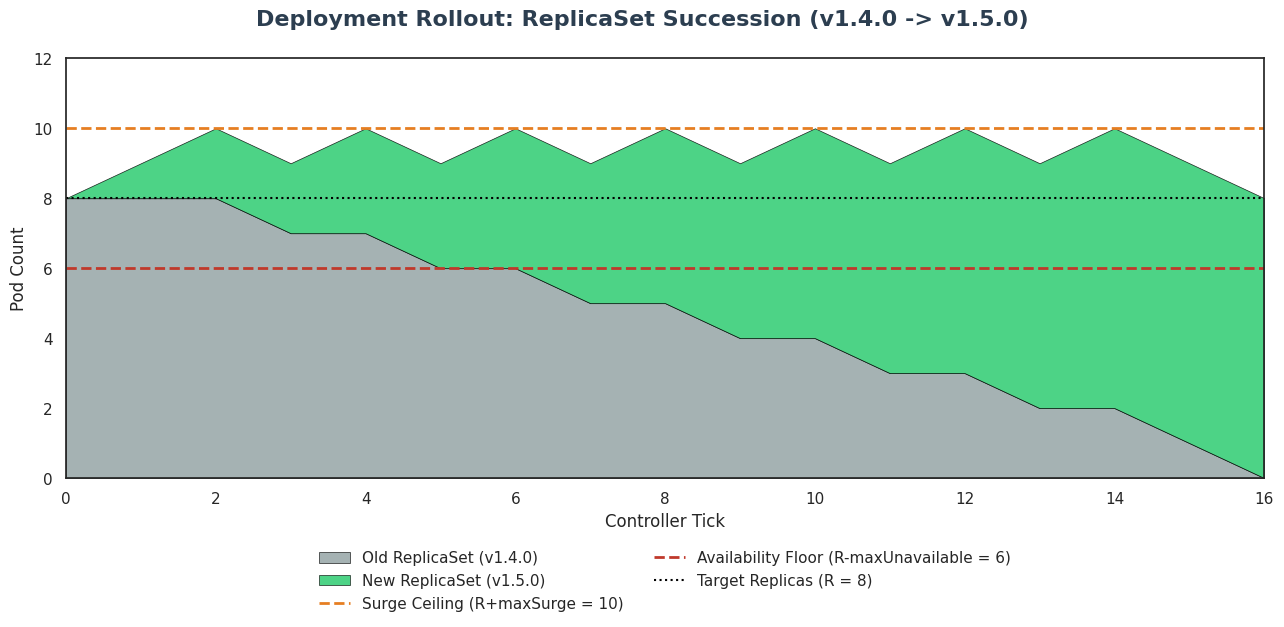

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="white")

ticks = list(range(len(trajectory)))
old_series = [t[0] for t in trajectory]
new_series = [t[1] for t in trajectory]

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.suptitle("Deployment Rollout: ReplicaSet Succession (v1.4.0 -> v1.5.0)", fontsize=16, fontweight='bold', color="#2c3e50")

ax.stackplot(ticks, old_series, new_series, labels=["Old ReplicaSet (v1.4.0)", "New ReplicaSet (v1.5.0)"],
             colors=["#95a5a6", "#2ecc71"], alpha=0.85, edgecolor="black", linewidth=0.5)

ax.axhline(R + max_surge, color="#e67e22", ls="--", lw=2, label=f"Surge Ceiling (R+maxSurge = {R + max_surge})")
ax.axhline(R - max_unavailable, color="#c0392b", ls="--", lw=2, label=f"Availability Floor (R-maxUnavailable = {R - max_unavailable})")
ax.axhline(R, color="black", ls=":", lw=1.5, label=f"Target Replicas (R = {R})")

ax.set_xlabel("Controller Tick")
ax.set_ylabel("Pod Count")
ax.set_xlim(0, len(ticks) - 1)
ax.set_ylim(0, R + max_surge + 2)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False)

plt.tight_layout()
plt.show()


*(Insight: The gray region (old version) shrinks monotonically while the green region (new version) grows monotonically -- they never both hit zero or empty at the same tick, which is exactly the "always some capacity serving traffic" guarantee. The combined stack briefly pokes above the black target line into the orange surge ceiling, but never dips below the red availability floor -- the two dashed bounds are the entire safety contract a RollingUpdate strategy enforces.)*

## Real-World Use Case or Analogy

Think of a RollingUpdate Deployment as **The Bridge Repair Convoy**:

* **The Deployment (The Repair Contract):** The city contracts to replace every worn plank on a footbridge with new, stronger planks -- the "desired state" is: 100% new planks, 0% old planks.
* **maxUnavailable (Minimum Planks That Must Stay Down):** The contract legally requires the bridge to always have at least 75% of its walking surface intact -- workers can never pull up more planks than that limit allows, or pedestrians fall through.
* **maxSurge (Temporary Scaffolding Overhang):** To move faster, the crew is allowed to bolt a few *extra* temporary planks alongside the old ones before removing anything -- briefly widening the bridge past its normal width to keep both old and new walking surfaces available at once.
* **Readiness Probes (The Structural Inspector):** Before a new plank counts as "safe to walk on," an inspector tests it under load for a sustained period (`minReadySeconds`) -- a plank that wobbles never gets counted, no matter how long the crew waits.
* **A Stalled Rollout (A Bad Batch of Planks):** If the new plank shipment is defective and none pass inspection, the crew simply stops pulling up old planks -- the bridge stays safe but the repair visibly never finishes, which is the signal to call `kubectl rollout undo` and send the bad batch back.
* **The ReplicaSet Chain (Renovation Log):** Every past renovation (revision) is kept on file, so if this batch of planks turns out defective weeks later, the city can point to exactly which shipment and instantly revert to the last known-good layout.

The entire strategy reduces to one sentence: never remove more capacity than `maxUnavailable` allows, never add more than `maxSurge` allows, and never trust a replacement until it has proven itself ready -- the same three rules whether you are replacing footbridge planks or container images.